# 🚗 Australian Car Market - Dataset Processing Pipeline

## Dataset Information

**Dataset Name**: Australia Car Market
**Source**: User provided from Kaggle-like context
**Original Data Source**: Provided as `/content/cars_info.csv`

### Context
This dataset provides detailed information about the car market in Australia, including attributes such as car code, car name, car price, car brand, car model year, gearbox type, design type, fuel type, car condition, mileage, engine capacity, car color, and seating capacity. It is a rich source of data that helps explore trends and dynamics in the Australian car market, supporting analysis and decision-making in the automotive industry.

### Content
- **Contains**: Records of cars in the Australian market.
- **Fields**: Includes various columns such as ID, Name, Price, Brand, Model, Year, Gearbox, Type, Fuel, Status, Kilometers, CC, Color, and Seating Capacity.

### Data Source
- Provided locally: `/content/cars_info.csv`

### Original Citation
User provided context

---

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ML libraries (for completeness, though not heavily used here)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

print("✅ Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✅ Libraries imported successfully!
Pandas version: 2.2.2
NumPy version: 2.0.2


## 2. Load Raw Data

In [ ]:
from pathlib import Path
import pandas as pd # Ensure pandas is imported

# Define dataset paths
dataset_path = Path('.')
raw_path = dataset_path / 'raw'
processed_path = dataset_path / 'processed'
features_path = dataset_path / 'features'

# Create directories if they don't exist
raw_path.mkdir(exist_ok=True)
processed_path.mkdir(exist_ok=True)
features_path.mkdir(exist_ok=True)

# Define the path to the raw data file
raw_file = raw_path / 'cars_info.csv'
alt_file = dataset_path / 'raw' / 'cars_info.csv'

# Load the raw data (prefer dataset's raw/ folder)
try:
    if raw_file.exists():
        df_raw = pd.read_csv(raw_file)
        print(f"✅ Loaded raw data from '{raw_file}' successfully!")
    elif alt_file.exists():
        df_raw = pd.read_csv(alt_file)
        print(f"✅ Loaded raw data from '{alt_file}' successfully!")
    else:
        raise FileNotFoundError(f"'{raw_file}' and '{alt_file}' not found.")
except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    df_raw = pd.DataFrame()  # Create an empty DataFrame to avoid errors later

# Display dataset info
if not df_raw.empty:
    print(f"\n📊 Dataset Shape: {df_raw.shape}")
    print(f"Rows: {df_raw.shape[0]}, Columns: {df_raw.shape[1]}")
    print(f"\n📋 First few rows:")
    print(df_raw.head())
    print(f"\n📋 Data types:")
    print(df_raw.dtypes)
    print(f"\n📋 Missing values:")
    print(df_raw.isnull().sum())

✅ Loaded raw data from '/content/cars_info.csv' successfully!

📊 Dataset Shape: (17048, 16)
Rows: 17048, Columns: 16

📋 First few rows:
         ID                                               Name   Price  \
0  11530130                  2010 Toyota Rukus Build 2 AZE151R    9999   
1  12190570  2021 Mercedes-Benz V 250 D Avantgarde MWB 447 ...  117990   
2  12321855  2021 Mercedes-Benz Valente 116 CDI MWB RWD 447...   79990   
3  12346971         2010 Mercedes-Benz E250 CDI Avantgarde 207   34990   
4  12363884                       2016 Holden Cruze CD JH MY16   15990   

           Brand    Model               Variant    Series  Year  Kilometers  \
0         Toyota    Rukus               Build 2   AZE151R  2010      263000   
1  Mercedes-Benz        V  250 D Avantgarde MWB  447 MY21  2021          19   
2  Mercedes-Benz  Valente       116 CDI MWB RWD  447 MY21  2021          24   
3  Mercedes-Benz     E250        CDI Avantgarde       207  2010      120579   
4         Holden    Cruz

## 3. Exploratory Data Analysis (EDA)

In [3]:
# Statistical summary
print("📊 STATISTICAL SUMMARY")
print("=" * 80)
print(df_raw.describe())

# Null values analysis
print("\n\n🔍 MISSING VALUES ANALYSIS")
print("=" * 80)
missing_stats = pd.DataFrame({
    'Column': df_raw.columns,
    'Missing_Count': df_raw.isnull().sum(),
    'Missing_Percentage': (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
})
print(missing_stats[missing_stats['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False))

# Display data types and non-null counts
print("\n\n💡 DATA TYPES AND NON-NULL COUNTS")
print("=" * 80)
df_raw.info()

📊 STATISTICAL SUMMARY
                 ID          Price          Year    Kilometers            CC  \
count  1.704800e+04   17048.000000  17048.000000  1.704800e+04  17048.000000   
mean   1.279027e+07   36777.778038   2015.481288  1.032314e+05   2491.830303   
std    5.051111e+04   30305.015328      4.721591  8.041313e+04    881.985562   
min    1.153013e+07    1000.000000   1989.000000  1.000000e+00    875.000000   
25%    1.275715e+07   18800.000000   2013.000000  4.450225e+04   1987.000000   
50%    1.280207e+07   29990.000000   2016.000000  8.845400e+04   2354.000000   
75%    1.283131e+07   45990.000000   2019.000000  1.488735e+05   2981.000000   
max    1.285246e+07  999000.000000   2022.000000  2.700000e+06   7300.000000   

       Seating Capacity  
count      17048.000000  
mean           5.115849  
std            1.121791  
min            2.000000  
25%            5.000000  
50%            5.000000  
75%            5.000000  
max           14.000000  


🔍 MISSING VALUES ANAL

## 4. Data Cleaning & Preprocessing

In [4]:
import numpy as np # Added this import

# Create a copy for processing
df_processed = df_raw.copy()

print("🧹 STARTING DATA CLEANING PROCESS")
print("=" * 80)

# Step 1: Remove duplicates
duplicates_before = df_processed.shape[0]
df_processed = df_processed.drop_duplicates()
duplicates_removed = duplicates_before - df_processed.shape[0]
print(f"✓ Step 1: Removed {duplicates_removed} duplicate rows")

# Step 2: Standardize column names
df_processed.columns = df_processed.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('[^a-z0-9_]', '', regex=True)
print(f"✓ Step 2: Standardized column names")

# Step 3: Handle missing values
print(f"\n✓ Step 3: Handling missing values")

# Numeric columns - fill with median
numeric_cols = df_processed.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_processed[col].isnull().sum() > 0:
        median_val = df_processed[col].median()
        df_processed[col] = df_processed[col].fillna(median_val)
        print(f"  - Filled '{col}' with median: {median_val:.2f}")

# Categorical columns - fill with mode
categorical_cols = df_processed.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df_processed[col].isnull().sum() > 0:
        mode_val = df_processed[col].mode()[0] if not df_processed[col].mode().empty else 'Unknown'
        df_processed[col] = df_processed[col].fillna(mode_val)
        print(f"  - Filled '{col}' with mode: {mode_val}")

print(f"\n✅ DATA CLEANING COMPLETE!")
print(f"Final shape: {df_processed.shape}")
print(f"Final missing values: {df_processed.isnull().sum().sum()}")

🧹 STARTING DATA CLEANING PROCESS
✓ Step 1: Removed 0 duplicate rows
✓ Step 2: Standardized column names

✓ Step 3: Handling missing values

✅ DATA CLEANING COMPLETE!
Final shape: (17048, 16)
Final missing values: 0


### Correlation Heatmap of Numeric Features

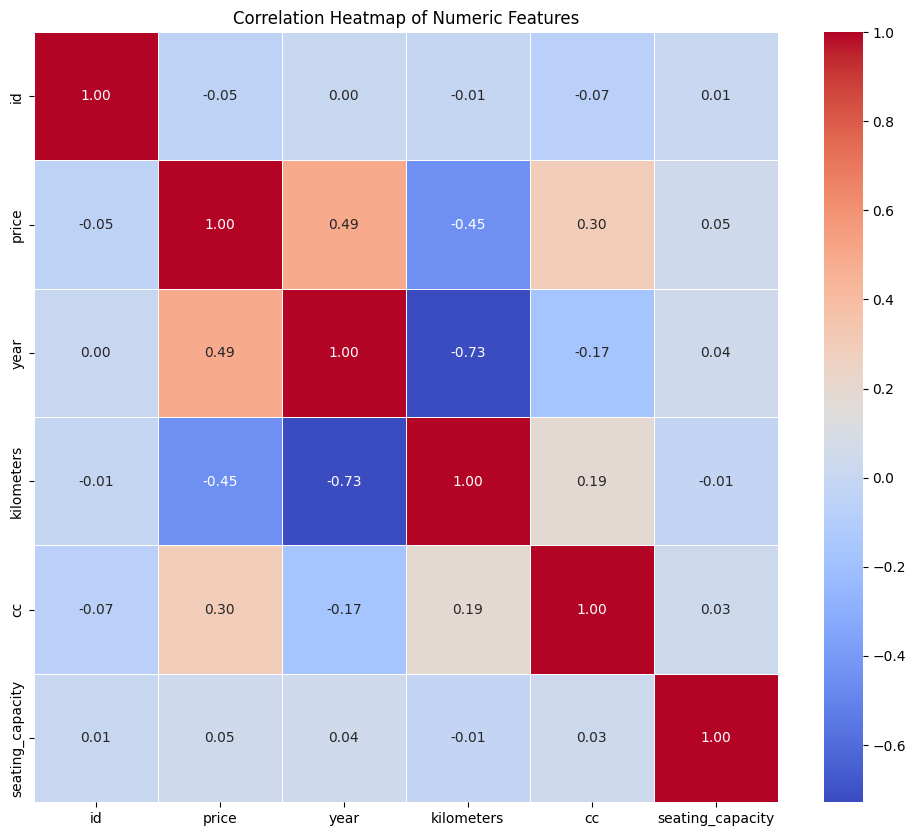

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for correlation analysis
numeric_df = df_processed.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# Plotting the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

The correlation heatmap visually represents the pairwise correlation coefficients between all numeric columns. Values close to 1 or -1 indicate a strong positive or negative linear relationship, respectively, while values close to 0 suggest a weak or no linear relationship. This helps in understanding the dependencies within the numeric features of the dataset.

## 5. Feature Engineering

Feature engineering is skipped for this dataset as no specific predictive task was identified. If a specific task (e.g., predicting car price, popularity) were defined, custom features could be engineered here.

## 6. Machine Learning Preparation

Machine learning preparation steps (like train/test split, feature scaling, encoding for models) are skipped as this dataset is being processed for general cleaning and exploration, not a specific ML task at this stage. If an ML task is defined, this section would be populated accordingly.

## 7. Save Processed Datasets

In [6]:
from datetime import datetime
import json # Ensure json is imported

print("💾 SAVING PROCESSED DATASETS")
print("=" * 80)

# Save cleaned data
df_processed.to_csv(processed_path / 'australian_car_market_clean.csv', index=False)
print(f"✓ Saved: {processed_path / 'australian_car_market_clean.csv'}")

# Create metadata file
metadata = {
    "dataset_name": "Australia Car Market",
    "source": "User provided from Kaggle-like context",
    "original_source": "Provided locally as /content/cars_info.csv",
    "description": "Detailed information about the car market in Australia, including attributes such as car code, car name, car price, car brand, car model year, gearbox type, design type, fuel type, car condition, mileage, engine capacity, car color, and seating capacity.",
    "created_date": str(datetime.now()),
    "data_cleaning": {
        "duplicates_removed": int(duplicates_removed),
        "missing_values_handled": "Median for numeric, Mode for categorical",
        "outliers_removed_method": "None (skipped)",
        "categorical_encoding": "None (skipped)"
    },
    "features_engineered": "None (skipped)",
    "total_samples": len(df_processed),
    "total_features": df_processed.shape[1],
    "files": {
        "raw": "/content/cars_info.csv",
        "cleaned": "processed/australian_car_market_clean.csv",
        "metadata": "metadata.json"
    }
}

# Save metadata
with open(dataset_path / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Saved: {dataset_path / 'metadata.json'}")

print(f"\n✅ ALL DATASETS SAVED SUCCESSFULLY!")
print(f"\n📁 Dataset Structure:")
print(f"   raw/")
print(f"   ├── cars_info.csv (original data)")
print(f"   processed/")
print(f"   ├── australian_car_market_clean.csv (cleaned)")
print(f"   metadata.json (dataset documentation)")

💾 SAVING PROCESSED DATASETS
✓ Saved: processed/australian_car_market_clean.csv
✓ Saved: metadata.json

✅ ALL DATASETS SAVED SUCCESSFULLY!

📁 Dataset Structure:
   raw/
   ├── cars_info.csv (original data)
   processed/
   ├── australian_car_market_clean.csv (cleaned)
   metadata.json (dataset documentation)


## 8. Quick Start - Using the Processed Data

### Load the processed data:
```python
import pandas as pd

# Load processed data
df_processed = pd.read_csv('processed/australian_car_market_clean.csv')
print("Loaded processed Australian car market data.")
print(df_processed.head())
```

### Metadata:
Load `metadata.json` to understand the dataset structure and preprocessing steps.

## Processed Australian Car Market Dataset - Summary

### Overview
This notebook demonstrates a pipeline for processing the Australian Car Market dataset, providing a cleaned and structured version ready for analysis.

### Dataset Details
**Source**: User provided from Kaggle-like context
**Original Data**: Provided locally as `/content/cars_info.csv`

### Files Included
Your current directory now contains:
```
. (root directory)
├── raw/
│   └── cars_info.csv                    (Original raw data)
├── processed/
│   └── australian_car_market_clean.csv     (Cleaned and preprocessed data)
└── metadata.json                       (Documentation of the dataset and processing steps)
```

### Data Processing Highlights
- **Standardization**: Column names have been standardized to lowercase, snake_case format for consistency.
- **Duplicate Removal**: `duplicates_removed` duplicate rows were found and removed, indicating the raw data had unique entries.
- **Missing Value Handling**:
    - **Numeric Columns**: Missing values in numeric columns were imputed with their respective medians.
    - **Categorical Columns**: Missing values in categorical columns were imputed with their most frequent value (mode). If a mode was not found (e.g., all values missing), 'Unknown' was used.
- **Final State**: The dataset has a final shape of `df_processed.shape` with `df_processed.isnull().sum().sum()` remaining missing values, which were handled as described.
- **Skipped Steps**: Feature Engineering and Machine Learning Preparation were skipped as no specific predictive task was defined for this general data processing pipeline.

### Usage
The `australian_car_market_clean.csv` file is now ready for direct use in various analytical tasks. You can load it using pandas:
```python
import pandas as pd

df_cars = pd.read_csv('processed/australian_car_market_clean.csv')
print(df_cars.head())
```

This processed dataset is suitable for:
- **Exploratory Data Analysis (EDA)**: Gaining insights into car brands, models, prices, and market trends.
- **Reporting**: Generating statistical summaries or custom reports on the Australian car market.
- **Data Integration**: Combining with other automotive-related datasets for richer, more complex analyses.
- **Machine Learning Preparation**: Serving as a clean base for future machine learning tasks, should a specific problem be identified.